## Bathymetry data generation

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df_read = pd.read_csv(
    "histogram_Aral_Sea_64m_UTM_0.csv",
    sep=";",          # delimiter 
    header=0,         # row number for column names
    decimal=",",       # decimal point character
    index_col=None,   # or a column name / index
    na_values=["NA", ""],  # treat these as NaN
)

df_delta = df_read[(df_read["Elevation"] < 65) & (df_read["Elevation"] >= -13)].copy()

df = df_read[(df_read["Elevation"] < 65) & (df_read["Elevation"] >= 11)].copy()


In [14]:
df_read_table = pd.read_csv(
    "Aral_Tabel.csv",
    sep=";",          # delimiter 
    header=0,         # row number for column names
    decimal=".",       # decimal point character
    index_col=None,   # or a column name / index
    na_values=["NA", ""],  # treat these as NaN
)


df_obs = df_read_table.copy()
df_obs["Elevation"] = df_obs['elevation']-17
#df = df_read[(df_read["Elevation"] < 65) & (df_read["Elevation"] >= 10)].copy(
df_obs.head()

,Year,Amudarya_Q,Amudarya_s,Syrdarya_Q,Syrdarya_s,Precipitation,Evaporation,elevation,Volume,Area,Salinity,Elevation
0,1950,41.0,0.47,11.9,0.57,9.22,66.06,52.82,1060.17,65273,10.17,35.82
1,1951,33.4,0.52,13.2,0.65,8.07,59.19,52.72,1054.14,64896,9.74,35.72
2,1952,55.2,0.41,18.8,0.58,8.78,62.62,52.70,1052.93,64822,10.67,35.70
3,1953,54.8,0.41,19.5,0.68,9.63,64.11,52.86,1063.12,65440,9.82,35.86
4,1954,55.1,0.41,21.1,0.64,10.87,62.87,53.12,1081.91,66649,10.21,36.12


In [15]:
df.tail()

,Area,Elevation
73,1.014236e+11,60.0
74,1.046918e+11,61.0
75,1.081077e+11,62.0
76,1.112685e+11,63.0
77,1.144057e+11,64.0


In [16]:
df['Area_km'] = df['Area']/1e6
df['Area_km'] = df['Area_km'].round(2)

df['delta_volume'] =   df['Area_km'] * 0.001
df["total_volume"] = df["delta_volume"].cumsum()


df_delta['Area_km'] = df_delta['Area']/1e6
df_delta['Area_km'] = df_delta['Area_km'].round(2)
df_delta["delta_area"] = df_delta["Area_km"].diff().fillna(0)

In [17]:
df.head()

,Area,Elevation,Area_km,delta_volume,total_volume
24,2.467648e+10,11.0,24676.48,24.67648,24.67648
25,2.476319e+10,12.0,24763.19,24.76319,49.43967
26,2.487869e+10,13.0,24878.69,24.87869,74.31836
27,2.503987e+10,14.0,25039.87,25.03987,99.35823
28,2.532017e+10,15.0,25320.17,25.32017,124.67840


Text(0.5, 1.0, 'Elevation - Volume')

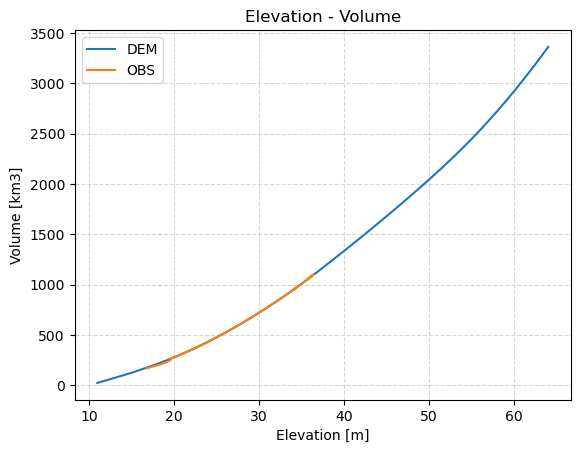

In [18]:
plt.plot(df['Elevation'],df['total_volume'], label='DEM')
plt.plot(df_obs['Elevation'],df_obs['Volume'], label = "OBS")
plt.grid(linestyle='--',alpha = 0.5)
plt.xlabel('Elevation [m]')
plt.ylabel('Volume [km3]')
plt.legend()
plt.title("Elevation - Volume")

Text(0.5, 1.0, 'Elevation - Area')

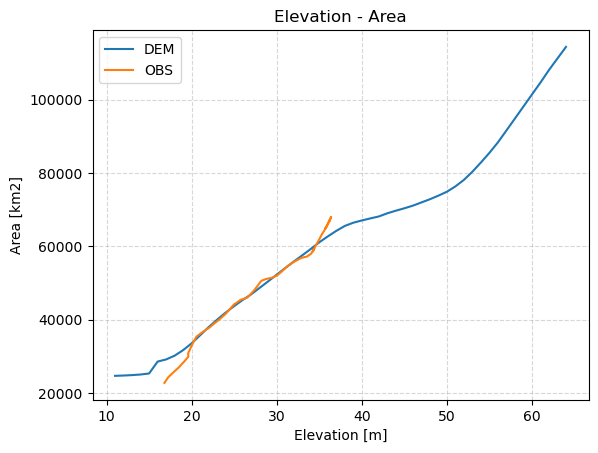

In [19]:
plt.plot(df['Elevation'],df['Area_km'], label = "DEM")
plt.plot(df_obs['Elevation'],df_obs['Area'], label = "OBS")
plt.grid(linestyle='--',alpha = 0.5)
plt.xlabel('Elevation [m]')
plt.ylabel('Area [km2]')
plt.legend()
plt.title("Elevation - Area")

Text(0.5, 1.0, 'Volume - Area')

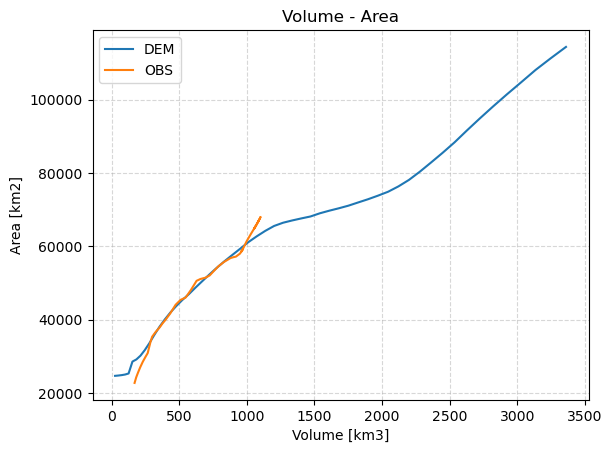

In [20]:
plt.plot(df['total_volume'],df['Area_km'],label="DEM")
plt.plot(df_obs['Volume'],df_obs['Area'], label="OBS")

plt.grid(linestyle='--',alpha = 0.5)
plt.xlabel('Volume [km3]')
plt.ylabel('Area [km2]')
plt.legend()
plt.title("Volume - Area")

Text(0.5, 1.0, 'Increase in Area')

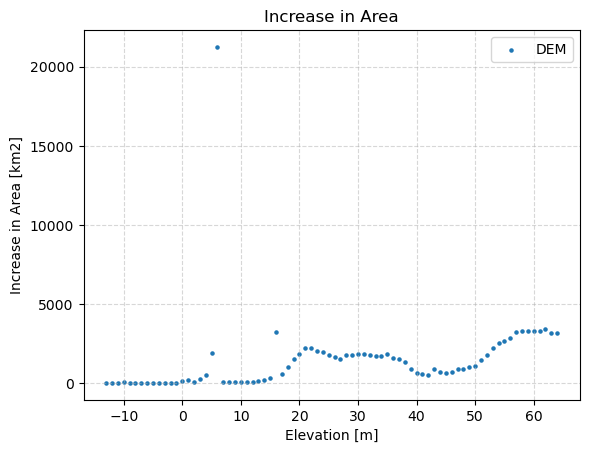

In [27]:
plt.scatter(df_delta['Elevation'],df_delta['delta_area'], label = 'DEM', s=5)

plt.grid(linestyle='--',alpha = 0.5)
plt.xlabel('Elevation [m]')
plt.ylabel('Increase in Area [km2]')
plt.legend(loc = 'best')
plt.title("Increase in Area")



In [22]:
df_obs.head()


,Year,Amudarya_Q,Amudarya_s,Syrdarya_Q,Syrdarya_s,Precipitation,Evaporation,elevation,Volume,Area,Salinity,Elevation
0,1950,41.0,0.47,11.9,0.57,9.22,66.06,52.82,1060.17,65273,10.17,35.82
1,1951,33.4,0.52,13.2,0.65,8.07,59.19,52.72,1054.14,64896,9.74,35.72
2,1952,55.2,0.41,18.8,0.58,8.78,62.62,52.70,1052.93,64822,10.67,35.70
3,1953,54.8,0.41,19.5,0.68,9.63,64.11,52.86,1063.12,65440,9.82,35.86
4,1954,55.1,0.41,21.1,0.64,10.87,62.87,53.12,1081.91,66649,10.21,36.12
